In [3]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, Column, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits

import os, sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
import kuaizi
from kuaizi.display import display_single
kuaizi.set_env(project='SBF', name='Rosesim', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')

import asdf
from astropy.time import Time
from astropy import units as u
import roman_datamodels as rdm
from romanisim import ris_make_utils as ris

In [4]:
sys.path.append('/home/jiaxuanl/Research/Rosesim/notebook/Rosesim')

In [5]:
from astropy.coordinates import SkyCoord
from ipyaladin import Aladin
from regions import Regions
from selectSIAF import defineApertures, getVertices, computeStcsFootprint, computeRegionFootprint
from getCatalog import gsss_stcsSearchUrl

import matplotlib.pyplot as plt
import os
import pysiaf
import time

ModuleNotFoundError: No module named 'selectSIAF'

## https://github.com/spacetelescope/mast_notebooks/blob/main/notebooks/multi_mission/display_footprints/display_footprints.ipynb

In [5]:
selectedTelescope = 'roman'
selectedInstrument = 'WFI'      # Allowed options ALL, WFI, CGI
selectedAperture = 'ALL'        # Allowed options ALL or individual apertures listed in instrument documentation

In [6]:
apertureList, V2Ref, V3Ref = defineApertures(selectedTelescope, selectedInstrument, selectedAperture)

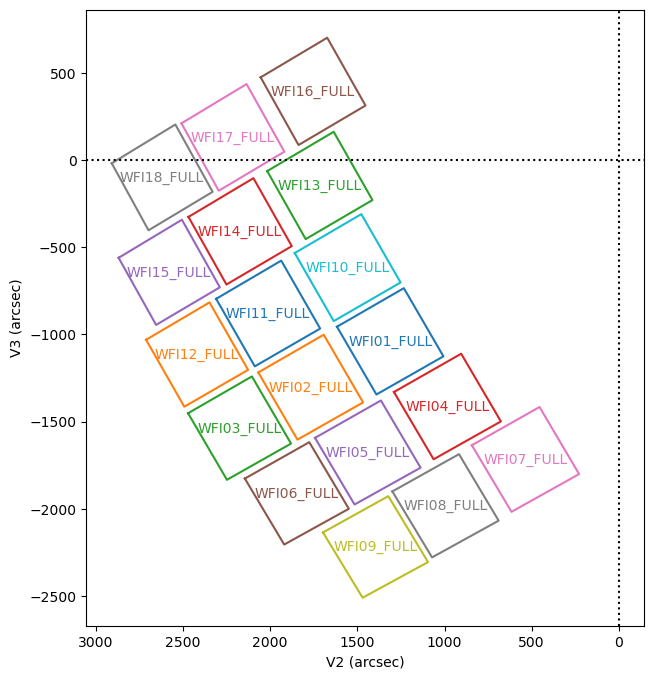

In [7]:
plt.figure(figsize=(8, 8), facecolor='w', edgecolor='k')
plt.gca().invert_xaxis()

# iterate through apertures, then plot
for aperture in apertureList:
    # circles are not properly plotted, skip
    if aperture.AperShape != 'CIRC':
        # set labels=False to remove them
        aperture.plot(label=True)

# Add guide lines for boresight (V2, V3) = (0, 0)
plt.axvline(color='k', linestyle=":")
plt.axhline(color='k', linestyle=":")

# Display the plot
plt.show() 

In [8]:
# coords = Mast.resolve_object("DDO046")
# coords

# Specify RA, Dec coordinates (This happens to be Arp 244)
coords = SkyCoord("13:03:16.8 -17:25:23",  unit=(u.hourangle, u.deg))

In [9]:
targetRa = coords.ra
targetDec = coords.dec

coords_str = coords.to_string()

# print out these values to check their conversions
print(f"RA:     {targetRa}\nDEC:    {targetDec}\nString: {coords_str}")

RA:     195.82 deg
DEC:    -17.423055555555557 deg
String: 195.82 -17.4231


In [77]:
# can be any value between 0 and 360
telescopePositionAngle = 60
attmat = pysiaf.utils.rotations.attitude_matrix(V2Ref, V3Ref, targetRa, targetDec, telescopePositionAngle)

    Need to add a dither pattern here

In [78]:
from shapely.geometry import Polygon

# Store polygons directly
polygons = []

# Loop through aperture list  (only works for QUAD, RECT, CIRC aperture shapes)
# Transform to sky coordinates, build footprints for passing to Aladin
combinedSregion = ''
for apertureSiaf in apertureList:
    apertureSiaf.set_attitude_matrix(attmat)
    xVertices, yVertices = getVertices(apertureSiaf)
    
    # Skip PICK which do not have vertices (HST/FGS is only instrument affected)
    if (xVertices is not None and yVertices is not None):
        skyRa, skyDec = apertureSiaf.idl_to_sky(xVertices, yVertices)
        
        # Create Shapely polygon directly from coordinates
        coord_pairs = list(zip(skyRa, skyDec))
        poly = Polygon(coord_pairs)
        polygons.append(poly)
        
        # Still create STC-S string if needed for Aladin
        apertureSregion = computeStcsFootprint(apertureSiaf, skyRa, skyDec)
        combinedSregion += apertureSregion

print(f"Created {len(polygons)} polygons")
# print('\n'+combinedSregion)

Created 18 polygons


In [79]:
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union

# Create a MultiPolygon
multi_poly = MultiPolygon(polygons)

# Or union all polygons into a single geometry
union_poly = unary_union(polygons)

print(f"Union geometry type: {union_poly.geom_type}")
print(f"Union bounds: {union_poly.bounds}")

Union geometry type: MultiPolygon
Union bounds: (195.39780144924802, -17.723228623183104, 196.24213775611156, -17.23156204717593)


In [80]:
from astropy.wcs import WCS
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from display import show_image_wcs
from astroquery.skyview import SkyView
SkyView.URL = 'https://skyview.gsfc.nasa.gov/current/cgi/basicform.pl'

In [81]:
r_ang = np.rad2deg(100 / 6000) * u.deg

In [82]:
# Get DSS image
hdu = SkyView.get_images(
    position=coords.to_string(),
    projection="Zea",
    survey="DSS",
    radius=1.5 * r_ang,
    pixels=(900, 900),
    scaling="Linear",
)[0]
img = hdu[0].data
w = WCS(hdu[0].header)

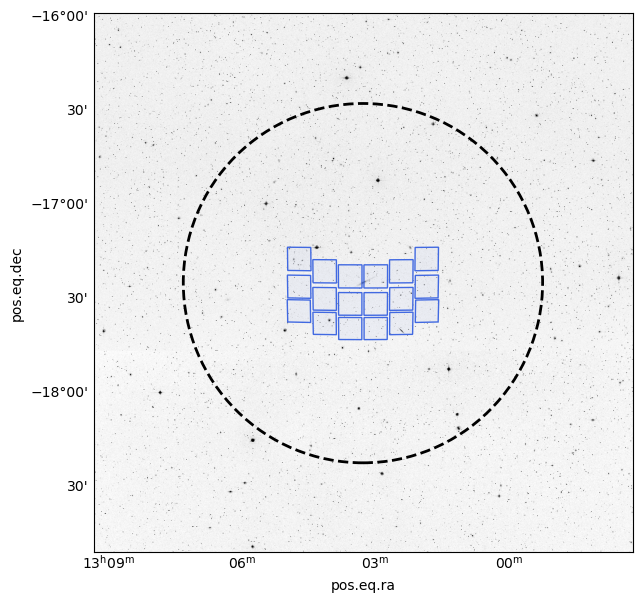

In [83]:
fig = plt.figure(figsize=(7, 7), frameon=False)
ax = plt.subplot(projection=w)
fig, ax, _ = show_image_wcs(img, fig=fig, ax=ax, cmap="Greys", percl=99.8)

geoms = polygons
for geom in geoms:
    edges = np.array(geom.exterior.xy).T
    p = mpatches.Polygon(
        edges,
        closed=True,
        lw=1,
        ls="-",
        edgecolor=to_rgba('royalblue', 1),
        clip_on=True,
        facecolor=to_rgba('royalblue', 0.05),
        transform=ax.get_transform("icrs"),
    )
    ax.add_artist(p)


ell = mpatches.Ellipse(
    (coords.ra.value, coords.dec.value),
    2 * r_ang.value / np.cos(np.deg2rad(coords.dec.value)),
    2 * r_ang.value,
    angle=0,
    zorder=10,
    lw=2,
    ls="--",
    transform=ax.get_transform("icrs"),
    edgecolor="k",
    facecolor="none",
)
ax.add_artist(ell)

In [12]:
# Loop through aperture list  (only works for QUAD, RECT, CIRC aperture shapes)
# Transform to sky coordinates, build footprints for passing to Aladin
combinedSregion = ''
for apertureSiaf in apertureList:
    apertureSiaf.set_attitude_matrix(attmat)
    xVertices, yVertices = getVertices(apertureSiaf)
    
    # Skip PICK which do not have vertices (HST/FGS is only instrument affected)
    if (xVertices is not None and yVertices is not None):
        skyRa, skyDec = apertureSiaf.idl_to_sky(xVertices, yVertices)
        apertureSregion = computeStcsFootprint(apertureSiaf, skyRa, skyDec)
        combinedSregion += apertureSregion
        
print('\n'+combinedSregion)


POLYGON ICRS 195.84059168 -17.44051851 195.72894391 -17.37905214 195.66275958 -17.48764977 195.77470576 -17.54852434 POLYGON ICRS 195.97208572 -17.51329481 195.86276389 -17.45324599 195.79695725 -17.56111121 195.90668895 -17.62041046 POLYGON ICRS 196.08951534 -17.57819866 195.98279395 -17.51969540 195.91743264 -17.62672448 196.02466051 -17.68433613 POLYGON ICRS 195.74539583 -17.54454057 195.63309666 -17.48345940 195.56660040 -17.59127397 195.67900391 -17.65171548 POLYGON ICRS 195.87735598 -17.61762243 195.76715374 -17.55808788 195.70079744 -17.66510566 195.81122807 -17.72384245 POLYGON ICRS 195.99472041 -17.68239436 195.88692479 -17.62451435 195.82081616 -17.73063771 195.92895215 -17.78759465 POLYGON ICRS 195.61510273 -17.62925313 195.50204073 -17.56822105 195.43570552 -17.67491984 195.54865043 -17.73531727 POLYGON ICRS 195.74797375 -17.70295360 195.63660859 -17.64351108 195.57013827 -17.74940117 195.68151278 -17.80804964 POLYGON ICRS 195.86403741 -17.76828496 195.75470428 -17.7105287

In [84]:
aladin = Aladin(height=600, fov=1, survey="P/DSS2/color", target=coords_str)
aladin

Aladin(survey='P/DSS2/color')

In [85]:
# Add the footprint with a hexcode for the color; you can also enter, e.g. "green"
aladin.add_overlay_from_stcs(combinedSregion, color="#70CBFF")

In [1]:
10**(0.2 * (26.5 + 2 - 25))

5.011872336272724